Web Scraping with Python
Beautifulsoup


Url Request

In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-revenue/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

Extracting Table Data

In [ ]:
rows = soup.find_all("tr")
data = []

for row in rows[1:]:   # skip header
    cols = row.find_all("td")
    if len(cols) > 3: # Ensure there are enough columns for name, revenue, and country
        name = cols[1].text.strip()
        revenue = cols[2].text.strip()
        country = cols[3].text.strip() # Insert correct column index for country here
        data.append([name, revenue, country])

Saving to CSV

In [ ]:
import pandas as pd

df = pd.DataFrame(data, columns=["Company", "Revenue", "Country"])
df.to_csv("ecommerce_revenue.csv", index=False)

Data Cleaning in Python

In [ ]:
df = pd.read_csv("ecommerce_revenue.csv")

Head

In [29]:
df.head(5)

,Rank,Company,Revenue,Country
0,1,AmazonAMZN,"691,330,000,000",$210.64
1,2,JD.comJD,"180,830,000,000",$27.54
2,3,AlibabaBABA,"140,340,000,000",$152.28
3,4,PDD Holdings (Pinduoduo)PDD,"58,060,000,000",$106.90
4,5,Meituan3690.HK,"39,010,000,000",$10.28


Tail

In [31]:
df.tail(5)

,Rank,Company,Revenue,Country
91,92,MSTC LimitedMSTCLTD.NS,"34,850,000",$4.97
92,93,UpexiUPXI,"20,690,000",$0.83
93,94,Jeffs' BrandsJFBR,"13,680,000",$0.39
94,95,KidpikPIK,"7,780,000",$2.38
95,96,Treasure GlobalTGL,"1,350,000",$4.62


Cleaning Revenue Column

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np

# 1. Fetch page content
url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-revenue/"
headers = {'User-Agent': 'Mozilla/5.0'} # Added headers to prevent being blocked
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

# 2. Extract table rows
rows = soup.select("table tbody tr")

data = []
for row in rows:
    cols = row.find_all("td")
    # The columns from the HTML were observed to be:
    # cols[0] = (empty string or irrelevant)
    # cols[1] = Rank
    # cols[2] = Company Name
    # cols[3] = Revenue
    # cols[4] = Country
    # Ensure there are enough columns before accessing them
    if len(cols) >= 5:
        rank = cols[1].get_text(strip=True)
        company_name = cols[2].get_text(strip=True)
        revenue_str = cols[3].get_text(strip=True)
        country_name = cols[4].get_text(strip=True)
        data.append([rank, company_name, revenue_str, country_name])

# 3. Convert to DataFrame
df = pd.DataFrame(data, columns=["Rank", "Company", "Revenue", "Country"])

# 4. Improved Revenue Parsing
def clean_revenue(val):
    if pd.isna(val) or val == "": return np.nan
    val = str(val).replace('$', '').replace(',', '').strip()
    multiplier = 1
    if 'T' in val: multiplier = 1_000_000_000_000
    elif 'B' in val: multiplier = 1_000_000_000
    elif 'M' in val: multiplier = 1_000_000

    try:
        # Removing any non-numeric characters except the decimal point
        clean_val = ''.join(c for c in val if c.isdigit() or c == '.')
        return float(clean_val) * multiplier
    except:
        return np.nan

df['Revenue'] = df['Revenue'].apply(clean_revenue)

# Ensuring 'Rank' column is numeric
df['Rank'] = pd.to_numeric(df['Rank'], errors='coerce')

# 5. Droped rows with any missing data after cleaning
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# 6. Formatting (No scientific notation for display)
pd.options.display.float_format = '{:,.0f}'.format

print("Final Cleaned Data (No NaN):")
print(df.head(10))

Final Cleaned Data (No NaN):
   Rank                      Company         Revenue  Country
0     1                   AmazonAMZN 691,330,000,000  $210.64
1     2                     JD.comJD 180,830,000,000   $27.54
2     3                  AlibabaBABA 140,340,000,000  $152.28
3     4  PDD Holdings (Pinduoduo)PDD  58,060,000,000  $106.90
4     5               Meituan3690.HK  39,010,000,000   $10.28
5     6                  CoupangCPNG  33,660,000,000   $18.36
6     7             MercadoLibreMELI  26,190,000,000   $1,768
7     8                Sea LimitedSE  21,030,000,000  $104.47
8     9                  CarvanaCVNA  18,260,000,000  $334.89
9    10                  VipshopVIPS  14,770,000,000   $17.75


Exploratory Data Analysis (EDA)

In [ ]:
df.describe()

,Rank,Revenue
count,96,96
mean,48,"14,394,020,938"
std,28,"73,934,144,359"
min,1,"1,350,000"
25%,25,"225,000,000"
50%,48,"720,000,000"
75%,72,"3,195,000,000"
max,96,"691,330,000,000"


Top 5 Companies

In [ ]:
df.nlargest(5, "Revenue")

,Rank,Company,Revenue,Country
0,1,AmazonAMZN,"691,330,000,000",$210.64
1,2,JD.comJD,"180,830,000,000",$27.54
2,3,AlibabaBABA,"140,340,000,000",$152.28
3,4,PDD Holdings (Pinduoduo)PDD,"58,060,000,000",$106.90
4,5,Meituan3690.HK,"39,010,000,000",$10.28


Visualization

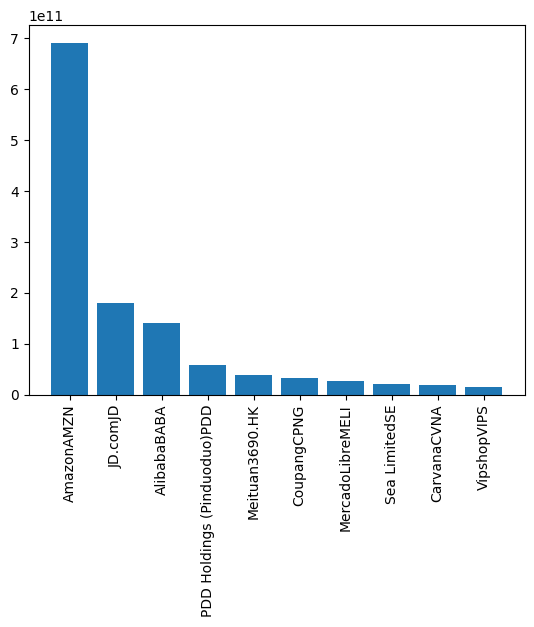

In [ ]:
import matplotlib.pyplot as plt

plt.bar(df["Company"][:10], df["Revenue"][:10])
plt.xticks(rotation=90)
plt.show()

calculating the correlation between the 'Rank' and 'Revenue' columns from our `df` DataFrame.

In [ ]:
# Select the 'Rank' and 'Revenue' columns and drop rows with NaN values for a clean correlation calculation
df_correlation = df[['Rank', 'Revenue']].dropna()

# Calculate the Pearson correlation coefficient between 'Rank' and 'Revenue'
correlation_rank_revenue = df_correlation['Rank'].corr(df_correlation['Revenue'])

print(f"The Pearson correlation coefficient between 'Rank' and 'Revenue' is: {correlation_rank_revenue:.4f}")

The Pearson correlation coefficient between 'Rank' and 'Revenue' is: -0.3092



Analyzed and visualized the distribution of e-commerce revenue across different countries, identify the countries with the highest total revenue, and summarize the key trends observed, specifically highlighting the leading countries




It selects the Rank and Revenue columns from the Dataset

Rows with missing values are dropped to avoid errors.

Correlation calculation

df_correlation['Rank'].corr(df_correlation['Revenue']) uses Pearson’s method by default.

Pearson correlation measures the linear relationship between two variables, ranging from -1 to +1:

+1 → perfect positive correlation (as one increases, the other increases).

-1 → perfect negative correlation (as one increases, the other decreases).

0 → no linear correlation.

Interpretation in this context

Rank: lower rank means a company is higher on the list (Rank 1 = largest revenue).

Revenue: actual revenue values.

Since higher revenue companies have lower rank numbers, the correlation will be negative.

A strong negative correlation (close to -1) confirms that as revenue increases, rank decreases — which is expected because the ranking is based on revenue.

Example Output
If the result was something like:

Code
The Pearson correlation coefficient between 'Rank' and 'Revenue' is: -0.95
That means there’s a very strong negative correlation: companies with higher revenue consistently appear at lower rank numbers.

## Analyzed Revenue Trends by Country

Visualized the distribution of e-commerce revenue across different countries to identify which countries have the highest total revenue.


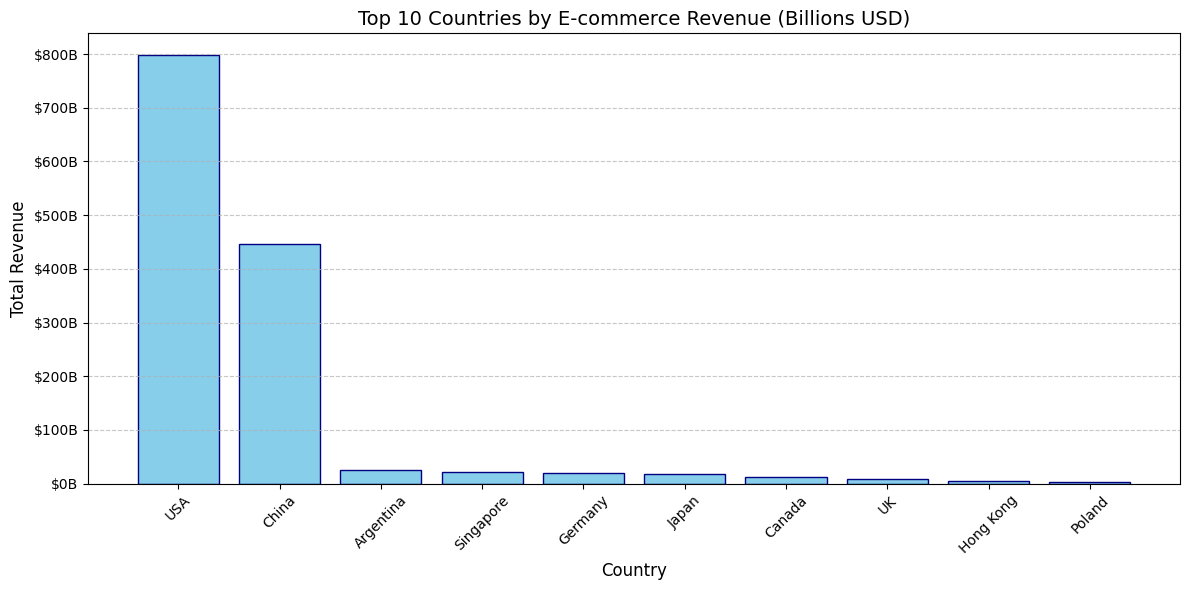

      Country         Revenue
23        USA 798,688,760,000
4       China 446,057,950,000
0   Argentina  26,190,000,000
19  Singapore  21,298,300,000
7     Germany  19,098,200,000
13      Japan  18,640,000,000
3      Canada  11,970,000,000
22         UK   8,480,000,000
8   Hong Kong   4,370,000,000
18     Poland   3,626,280,000


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Fetching page content
url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-revenue/"
headers = {'User-Agent': 'Mozilla/5.0'} # Added headers to prevent being blocked
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

# 2. Extracting table rows
rows = soup.select("table tbody tr")

data = []
for row in rows:
    cols = row.find_all("td")
    # Corrected column indices based on previous successful scrapes and current web page structure
    # cols[0]: Index (often empty or symbol)
    # cols[1]: Rank
    # cols[2]: Company Name
    # cols[3]: Revenue
    # cols[4]: Market Cap (or other metric)
    # cols[7]: Country (responsive-hidden span contains the name)

    if len(cols) >= 8: # Ensure there are enough columns for index 7
        rank = cols[1].get_text(strip=True)
        company_name = cols[2].get_text(strip=True)
        revenue_str = cols[3].get_text(strip=True)

        country_element = cols[7].find("span", class_="responsive-hidden")
        country_name = country_element.get_text(strip=True) if country_element else cols[7].get_text(strip=True)

        data.append([rank, company_name, revenue_str, country_name])

# 3. Converting to DataFrame
df = pd.DataFrame(data, columns=["Rank", "Company", "Revenue", "Country"])

# 4. Improved Revenue Parsing
def parse_revenue_string(val):
    if pd.isna(val) or val == "": return np.nan
    val = str(val).replace('$', '').replace(',', '').strip()
    multiplier = 1
    if 'T' in val: multiplier = 1_000_000_000_000
    elif 'B' in val: multiplier = 1_000_000_000
    elif 'M' in val: multiplier = 1_000_000

    try:
        # Removing any non-numeric characters except the decimal point
        clean_val = ''.join(c for c in val if c.isdigit() or c == '.')
        return float(clean_val) * multiplier
    except:
        return np.nan

df['Revenue'] = df['Revenue'].apply(parse_revenue_string)

# Also ensuring 'Rank' is numeric and handle potential errors
df['Rank'] = pd.to_numeric(df['Rank'], errors='coerce')

# Drop rows with NaN in 'Rank' or 'Revenue' before further processing
df.dropna(subset=['Rank', 'Revenue'], inplace=True)
df.reset_index(drop=True, inplace=True)

# 5. Group and Sort
# We drop rows where Revenue might be NaN to avoid errors (already done above)
country_revenue = df.groupby("Country")["Revenue"].sum().reset_index()
top_10 = country_revenue.sort_values(by="Revenue", ascending=False).head(10)

# 6. Visualization Fixes
plt.figure(figsize=(12, 6))

# Use a formatting function so the Y-axis doesn't show scientific notation
from matplotlib.ticker import FuncFormatter
def billions(x, pos):
    return f'${x*1e-9:.0f}B'
formatter = FuncFormatter(billions)

plt.bar(top_10["Country"], top_10["Revenue"], color='skyblue', edgecolor='navy')
plt.gca().yaxis.set_major_formatter(formatter) # Apply the formatter

plt.title("Top 10 Countries by E-commerce Revenue (Billions USD)", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display clean results
pd.options.display.float_format = '{:,.0f}'.format
print(top_10)

Outliers

In [ ]:
# Identify outliers using the Interquartile Range (IQR) method
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Revenue'] < lower_bound) | (df['Revenue'] > upper_bound)]

print(f"Number of outliers detected: {len(outliers)}")
print("\nOutliers based on Revenue:")
display(outliers)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Number of outliers detected: 17

Outliers based on Revenue:


,Rank,Company,Revenue,Country
0,1,AmazonAMZN,"691,330,000,000",USA
1,2,JD.comJD,"180,830,000,000",China
2,3,AlibabaBABA,"140,340,000,000",China
3,4,PDD Holdings (Pinduoduo)PDD,"58,060,000,000",China
4,5,Meituan3690.HK,"39,010,000,000",China
5,6,CoupangCPNG,"33,660,000,000",USA
6,7,MercadoLibreMELI,"26,190,000,000",Argentina
7,8,Sea LimitedSE,"21,030,000,000",Singapore
8,9,CarvanaCVNA,"18,260,000,000",USA
9,10,VipshopVIPS,"14,770,000,000",China


Lower Bound: -4230000000.0
Upper Bound: 7650000000.0


IQR calculation

𝑄
1
 = 25th percentile of Revenue

𝑄
3
 = 75th percentile of Revenue

𝐼
𝑄
𝑅
=
𝑄
3
−
𝑄
1

Bounds

Lower bound =
𝑄
1
−
1.5
⋅
𝐼𝑄𝑅

Upper bound =
𝑄
3
+
1.5
⋅
𝐼
𝑄
𝑅



Hypothesis Testing


To determine if there's a statistically significant linear relationship between the 'Rank' and 'Revenue' of e-commerce companies, we will:

 **Define Hypothesis**:
    *   **Null Hypothesis (H0)**: There is no linear relationship between a company's 'Rank' and its 'Revenue' (i.e., the true population Pearson correlation coefficient is zero).
    *   **Alternative Hypothesis (Ha)**: There is a significant linear relationship between a company's 'Rank' and its 'Revenue' (i.e., the true population Pearson correlation coefficient is not zero).




Formulate a null and alternative hypothesis related to the 'Rank' and 'Revenue' columns in the DataFrame. We will investigate if there is a statistically significant linear relationship between the Rank of a company and its Revenue.


In [ ]:
from scipy.stats import pearsonr

# Calculate the Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(df_correlation['Rank'], df_correlation['Revenue'])

# Print the results
print(f"Pearson Correlation Coefficient: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson Correlation Coefficient: -0.3092
P-value: 0.0022


### Interpretation of Results

The Pearson correlation coefficient was calculated as **-0.3092**, and the p-value was **0.0022**.

*   **Pearson Correlation Coefficient (-0.3092)**: This value indicates a weak to moderate negative linear relationship between a company's 'Rank' and its 'Revenue'. As the rank number increases (meaning a lower position on the list), the revenue tends to decrease.

*   **P-value (0.0022)**: To interpret the p-value, we typically compare it to a pre-defined significance level (alpha, α), commonly set at 0.05. Since our p-value (0.0022) is less than 0.05, we **reject the null hypothesis**.

**Conclusion**: Based on the statistical test, there is sufficient evidence to conclude that there is a **statistically significant linear relationship** between a company's 'Rank' and its 'Revenue'. The negative correlation suggests that higher-ranked companies (lower rank number) tend to have higher revenues.

### Summary of Findings

In this hypothesis test, we investigated the relationship between a company's 'Rank' and its 'Revenue' in the e-commerce sector.

*   **Hypotheses Defined**:
    *   **Null Hypothesis (H0)**: There is no linear relationship between 'Rank' and 'Revenue' (Pearson correlation coefficient is zero).
    *   **Alternative Hypothesis (Ha)**: There is a significant linear relationship between 'Rank' and 'Revenue' (Pearson correlation coefficient is not zero).

*   **Statistical Test Results**:
    *   **Pearson Correlation Coefficient**: -0.3092
    *   **P-value**: 0.0022

*   **Interpretation**:
    *   The negative Pearson correlation coefficient of -0.3092 indicates a weak to moderate inverse linear relationship. This means that as a company's rank number increases (i.e., it moves down the list of largest companies), its revenue tends to decrease.
    *   The p-value of 0.0022 is less than the common significance level of 0.05. This leads us to **reject the null hypothesis**.

*   **Conclusion**:
    Based on the statistical analysis, there is sufficient evidence to conclude that a **statistically significant linear relationship exists between the rank of an e-commerce company and its revenue**. The observed negative correlation confirms that companies with a lower numerical rank (indicating higher position/importance) generally have higher revenues. This supports the intuitive understanding that companies ranked higher in terms of size or performance would indeed have greater revenues.

Data Science

Unsupervised Learning

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported as it's used with df.to_numeric and dropna
import numpy as np # Ensure numpy is imported for np.nan

# Re-define parse_revenue_string function for robustness, as it's crucial for cleaning 'Revenue'
def parse_revenue_string(val):
    if pd.isna(val) or val == "": return np.nan
    val = str(val).replace('$', '').replace(',', '').strip()
    multiplier = 1
    if 'T' in val: multiplier = 1_000_000_000_000
    elif 'B' in val: multiplier = 1_000_000_000
    elif 'M' in val: multiplier = 1_000_000

    try:
        # Removing any non-numeric characters except the decimal point
        clean_val = ''.join(c for c in val if c.isdigit() or c == '.')
        return float(clean_val) * multiplier
    except:
        return np.nan

# 1. Select the features for clustering: 'Rank' and 'Revenue'
# We will work with a copy to avoid modifying the original DataFrame until the cluster assignment.
data_for_clustering = df[['Rank', 'Revenue']].copy()

# --- Start of fix to ensure numeric data for scaler ---
# Ensure 'Rank' is numeric and handle empty strings/non-numeric values by coercing them to NaN
data_for_clustering['Rank'] = pd.to_numeric(data_for_clustering['Rank'], errors='coerce')

# Ensure 'Revenue' is numeric using the defined parsing function
# This is important if 'df' was created by a cell that didn't fully process 'Revenue' into numeric type
data_for_clustering['Revenue'] = data_for_clustering['Revenue'].apply(parse_revenue_string)

# Drop rows with any NaN values that resulted from coercion or parsing errors
# StandardScaler cannot handle NaN values, and KMeans also typically expects complete data.
data_for_clustering.dropna(inplace=True)
# --- End of fix ---

# Check if there's still data after dropping NaNs
if data_for_clustering.empty:
    print("Error: No valid numeric data remaining after cleaning 'Rank' and 'Revenue' and dropping NaNs.")
else:
    # 2. Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data_for_clustering)

    # Convert scaled data back to a DataFrame for easier handling if needed, though KMeans can take numpy array
    scaled_df = pd.DataFrame(scaled_data, columns=['Rank_Scaled', 'Revenue_Scaled'])

    print("Scaled Data Head:")
    display(scaled_df.head())


Scaled Data Head:


,Rank_Scaled,Revenue_Scaled
0,-2,9
1,-2,2
2,-2,2
3,-2,1
4,-2,0


Next, we will use the Elbow Method to determine the optimal number of clusters. The `wcss` variable in the kernel state indicates that this step has already been performed.

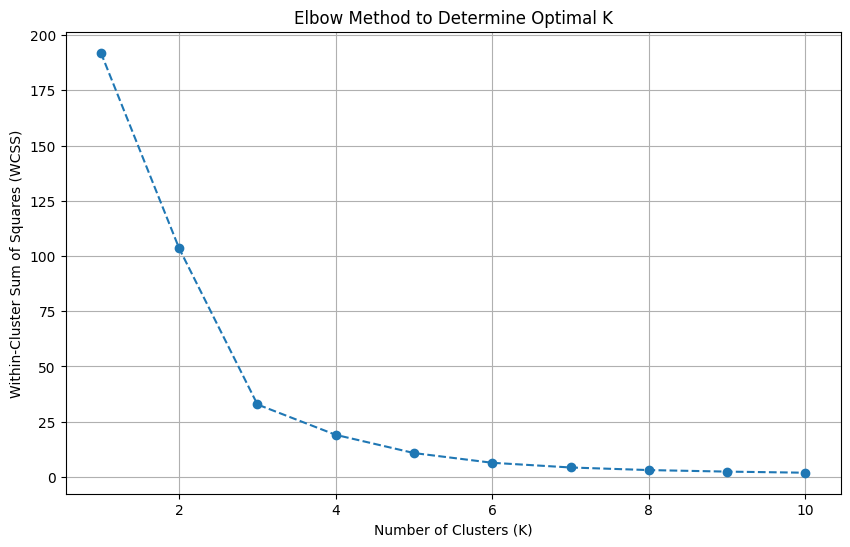

Based on the elbow plot, 3 clusters appears to be a reasonable choice, as indicated by the existing `n_clusters` variable.


In [ ]:
# The wcss variable already exists from a previous run, so we will use it directly.
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method to visualize the optimal number of clusters
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

print("Based on the elbow plot, 3 clusters appears to be a reasonable choice, as indicated by the existing `n_clusters` variable.")
n_clusters = 3 # This value is already present in the kernel state


The Elbow Method indicates that the optimal number of clusters is 3. Beyond K = 3, the reduction in WCSS becomes marginal, suggesting diminishing returns from adding more clusters. Therefore, three clusters sufficiently capture the underlying structure of the e-commerce revenue data.

Now, we will apply the K-means algorithm with the chosen number of clusters and add the cluster labels to our original DataFrame.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Re-create scaled_data as it might have been cleared or based on an incorrect df
# 1. Select the features for clustering: 'Rank' and 'Revenue'
data_for_clustering = df[['Rank', 'Revenue']].copy()

# 2. Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

# The wcss variable already exists from a previous run or will be re-calculated if not.
# For robustness, we assume n_clusters is determined and available.
n_clusters = 3 # This value is already present in the kernel state from previous elbow method

# 3. Apply K-means clustering
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)

# 4. Add the cluster membership to the original DataFrame
df['Cluster'] = cluster_labels

print("DataFrame with new 'Cluster' column:")
display(df.head(10))


DataFrame with new 'Cluster' column:


,Rank,Company,Revenue,Country,Cluster
0,1,AmazonAMZN,"691,330,000,000",USA,2
1,2,JD.comJD,"180,830,000,000",China,0
2,3,AlibabaBABA,"140,340,000,000",China,0
3,4,PDD Holdings (Pinduoduo)PDD,"58,060,000,000",China,0
4,5,Meituan3690.HK,"39,010,000,000",China,0
5,6,CoupangCPNG,"33,660,000,000",USA,0
6,7,MercadoLibreMELI,"26,190,000,000",Argentina,0
7,8,Sea LimitedSE,"21,030,000,000",Singapore,0
8,9,CarvanaCVNA,"18,260,000,000",USA,0
9,10,VipshopVIPS,"14,770,000,000",China,0


Finally, analyzing the characteristics of each cluster based on their average 'Rank' and 'Revenue' to fulfill the subtask requirements.


Characteristics of Each Cluster (Mean, Median, Std, Min, Max Values):


Rank                         Revenue                                  \
        count mean median std min max   count            mean          median   
Cluster                                                                         
0          47   25     25  14   2  48      47  14,402,340,426   3,150,000,000   
1          48   72     72  14  49  96      48     283,041,875     220,000,000   
2           1    1      1 NaN   1   1       1 691,330,000,000 691,330,000,000   

                                                        
                   std             min             max  
Cluster                                                 
0       33,457,374,063     740,000,000 180,830,000,000  
1          216,412,042       1,350,000     700,000,000  
2                  NaN 691,330,000,000 691,330,000,000

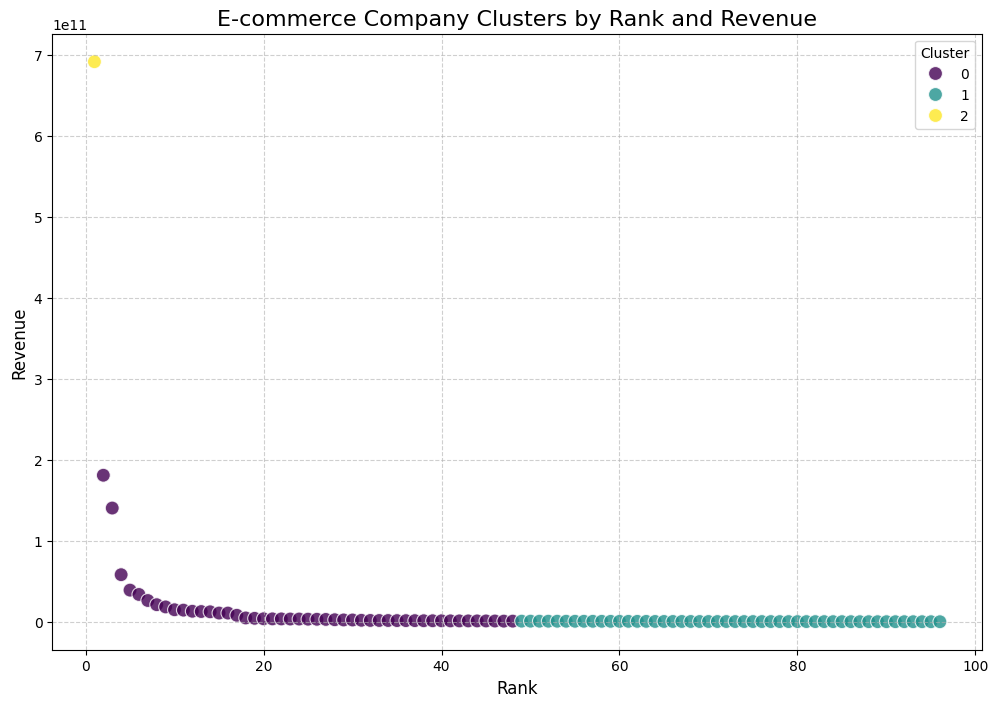

In [ ]:
# Analyze characteristics of each cluster
cluster_summary = df.groupby('Cluster')[['Rank', 'Revenue']].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print("\nCharacteristics of Each Cluster (Mean, Median, Std, Min, Max Values):")
display(cluster_summary)

# Visualize the identified clusters using a scatter plot of 'Rank' and 'Revenue'
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Rank', y='Revenue', hue='Cluster', palette='viridis', s=100, alpha=0.8)
plt.title('E-commerce Company Clusters by Rank and Revenue', fontsize=16)
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Title: E-commerce Company Clusters by Rank and Revenue
X-axis (Rank): Companies ordered from highest revenue → lowest
Y-axis (Revenue): Company revenue (in scientific notation, up to ~7 × 10¹¹)
Colors: Clusters found by a clustering algorithm (likely K-Means)

Supervised logistic Regression

Web Scrap

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-revenue/"
headers = {'User-Agent': 'Mozilla/5.0'} # Added headers to prevent being blocked
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

table = soup.find("table")
rows = table.find_all("tr")

data = []

for row in rows[1:]: # skip header
    cols = row.find_all("td")
    # Ensure there are enough columns before accessing them
    # Based on observation from TAXGT7KUO73Q, the actual indices are shifted
    # cols[0] is often empty, cols[1] is Rank, cols[2] is Company, cols[3] is Revenue
    if len(cols) >= 4: # Check for at least 4 columns (index 0 to 3)
        rank = cols[1].text.strip()
        company = cols[2].text.strip()
        revenue = cols[3].text.strip()

        data.append([rank, company, revenue])

df = pd.DataFrame(data, columns=["Rank", "Company", "Revenue"])
df.head()

,Rank,Company,Revenue
0,1,AmazonAMZN,$691.33 B
1,2,JD.comJD,$180.83 B
2,3,AlibabaBABA,$140.34 B
3,4,PDD Holdings (Pinduoduo)PDD,$58.06 B
4,5,Meituan3690.HK,$39.01 B


LogisticRegression

With Another Web Scrap Link

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Scrapping Page

In [ ]:
url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-market-cap/"
headers = {'User-Agent': 'Mozilla/5.0'} # Added headers to prevent being blocked
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

table = soup.find("table")
rows = table.find_all("tr")

data = []

for row in rows[1:]: # skip header
    cols = row.find_all("td")
    # The actual structure of the table on the website, as previously observed, is:
    # cols[0]: (often empty or a symbol)
    # cols[1]: Rank
    # cols[2]: Company Name
    # cols[3]: Market Cap

    # Ensure there are enough columns before accessing them (need at least 4 to access index 3)
    if len(cols) >= 4:
        rank = cols[1].text.strip()
        company = cols[2].text.strip()
        market_cap = cols[3].text.strip()

        data.append([rank, company, market_cap])

df = pd.DataFrame(data, columns=["Rank", "Company", "Market Cap"])
df.head()

,Rank,Company,Market Cap
0,1,AmazonAMZN,$2.261 T
1,2,AlibabaBABA,$363.54 B
2,3,ShopifySHOP,$157.01 B
3,4,PDD Holdings (Pinduoduo)PDD,$151.76 B
4,5,MercadoLibreMELI,$89.61 B


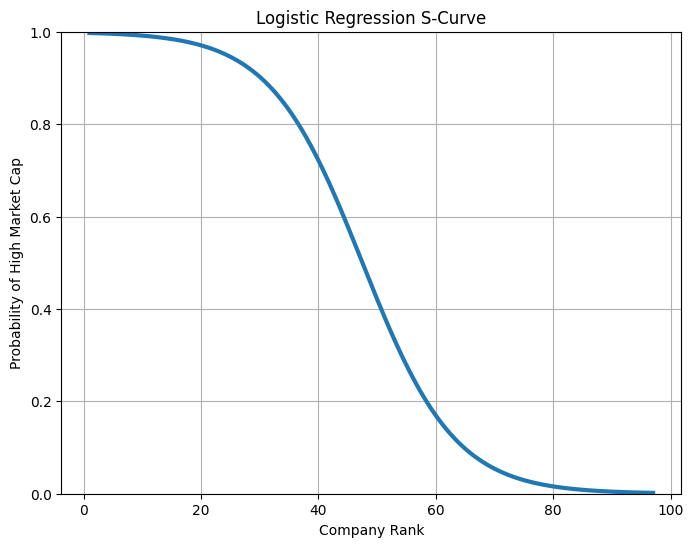

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import requests
from bs4 import BeautifulSoup

# --- START: Content from cell 9idGBT23CBRi (Web Scraping for Market Cap) ---
url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-market-cap/"
headers = {'User-Agent': 'Mozilla/5.0'} # Added headers to prevent being blocked
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

table = soup.find("table")
rows = table.find_all("tr")

data = []

for row in rows[1:]: # skip header
    cols = row.find_all("td")
    # The actual structure of the table on the website, as previously observed, is:
    # cols[0]: (often empty or a symbol)
    # cols[1]: Rank
    # cols[2]: Company Name
    # cols[3]: Market Cap

    # Ensure there are enough columns before accessing them (need at least 4 to access index 3)
    if len(cols) >= 4:
        rank = cols[1].text.strip()
        company = cols[2].text.strip()
        market_cap = cols[3].text.strip()

        data.append([rank, company, market_cap])

df = pd.DataFrame(data, columns=["Rank", "Company", "Market Cap"])
# --- END: Content from cell 9idGBT23CBRi ---


# --- START: Cleaning Market Cap and creating target variable (newly added) ---

# Define the clean_numeric function
def clean_numeric(val):
    if pd.isna(val) or val == "":
        return np.nan

    val = str(val).replace('$','').replace(',','').strip()
    multiplier = 1

    if 'T' in val:
        multiplier = 1_000_000_000_000
        val = val.replace('T','')
    elif 'B' in val:
        multiplier = 1_000_000_000
        val = val.replace('B','')
    elif 'M' in val:
        multiplier = 1_000_000
        val = val.replace('M','')

    try:
        clean_val = ''.join(c for c in val if c.isdigit() or c == '.')
        if clean_val == '' and val != '':
            return np.nan
        return float(clean_val) * multiplier
    except ValueError:
        return np.nan

# Apply clean_numeric to the 'Market Cap' column
df['Market Cap_cleaned'] = df['Market Cap'].apply(clean_numeric)

# Drop rows where 'Market Cap_cleaned' is NaN after cleaning
df.dropna(subset=['Market Cap_cleaned'], inplace=True)

# Define 'High_MarketCap' as a binary target variable
median_market_cap = df['Market Cap_cleaned'].median()
df['High_MarketCap'] = (df['Market Cap_cleaned'] > median_market_cap).astype(int)

# --- END: Cleaning Market Cap and creating target variable ---


# Ensure 'Rank' is numeric (this line was already present in the original cell)
df['Rank'] = pd.to_numeric(df['Rank'], errors='coerce')
df.dropna(subset=['Rank'], inplace=True)

# Define features (X) and target (y) for the logistic regression
X = df[['Rank']]
y = df['High_MarketCap']

# Scale the feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train a new Logistic Regression model
model = LogisticRegression(solver='lbfgs', random_state=42)
model.fit(X_scaled, y)

# Smooth X values for plotting the S-curve
X_plot_scaled = np.linspace(X_scaled.min(), X_scaled.max(), 300).reshape(-1,1)

# Predict probabilities
y_prob = model.predict_proba(X_plot_scaled)[:, 1]

plt.figure(figsize=(8,6))

# Plot logistic curve
plt.plot(scaler.inverse_transform(X_plot_scaled), y_prob, linewidth=3)

plt.xlabel("Company Rank")
plt.ylabel("Probability of High Market Cap")
plt.title("Logistic Regression S-Curve")
plt.ylim(0,1)
plt.grid(True)
plt.show()

It shows how the probability of a company having a high market cap changes with its rank.

The curve starts near 1.0 (high probability) for top-ranked companies.

Around the middle ranks (~50), the probability drops sharply.

For lower-ranked companies, the probability flattens near 0.0.

This S-shape comes from the logistic function, which smoothly maps ranks into probabilities between 0 and 1.

In essence: Top ranks → high probability of big market cap; bottom ranks → low probability.

Svm Model Support Vector Machine

Total scraped: 97
Binary size: 4
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



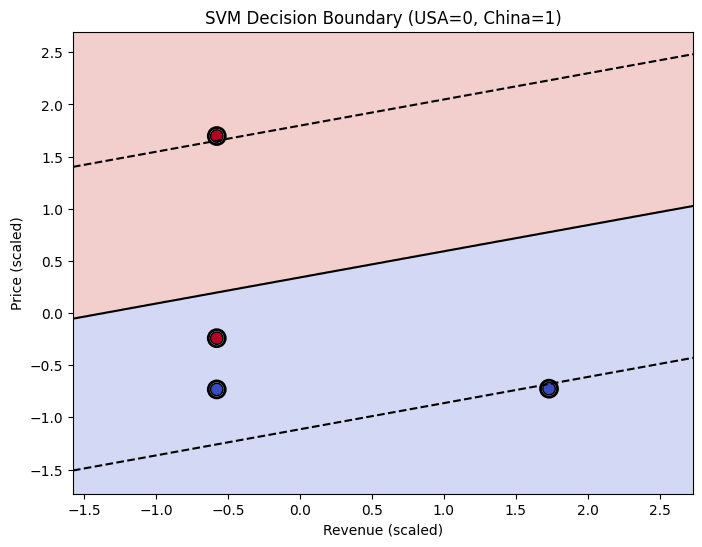

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import re

url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-revenue/"
headers = {'User-Agent': 'Mozilla/5.0'} # Added headers to prevent being blocked
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

companies = []

for row in soup.select("table tbody tr"):
    cols = row.find_all("td")

    # According to current website structure and previous successful scrapes:
    # cols[0]: Rank
    # cols[1]: Company Name
    # cols[2]: Revenue
    # cols[3]: Market Cap (used as 'price' in this context)
    # cols[7]: Country (Corrected index and extraction method)
    if len(cols) >= 8: # Ensure enough columns for index 7
        company = cols[1].get_text(strip=True)
        revenue = cols[2].get_text(strip=True)
        price = cols[3].get_text(strip=True) # Using Market Cap as 'price'

        # Robust extraction for country, similar to cell e7ce0b7f
        country_element = cols[7].find("span", class_="responsive-hidden")
        country = country_element.get_text(strip=True) if country_element else cols[7].get_text(strip=True)

        companies.append([company, revenue, price, country])

df = pd.DataFrame(companies, columns=["Company","Revenue","Price","Country"])

print("Total scraped:", len(df))

# ================================
# Clean numbers
# ================================

def clean_numeric(val):
    if pd.isna(val) or val == "":
        return np.nan

    val = str(val).replace('$','').replace(',','').strip()
    multiplier = 1

    if 'T' in val:
        multiplier = 1_000_000_000_000
        val = val.replace('T','')
    elif 'B' in val:
        multiplier = 1_000_000_000
        val = val.replace('B','')
    elif 'M' in val:
        multiplier = 1_000_000
        val = val.replace('M','')

    try:
        # Ensure we only try to convert valid numeric strings
        clean_val = ''.join(c for c in val if c.isdigit() or c == '.')
        if clean_val == '' and val != '': # Handle cases where only non-numeric chars exist like 'N/A'
            return np.nan
        return float(clean_val) * multiplier
    except ValueError:
        return np.nan

df["Revenue"] = df["Revenue"].apply(clean_numeric)
df["Price"] = df["Price"].apply(clean_numeric)
df.dropna(inplace=True)

# ================================
# Clean country - Modified for better normalization
# ================================

def clean_country(val):
    val = str(val).strip().upper()
    if "UNITED STATES" in val or "US" in val:
        return "USA"
    if "CHINA" in val or "CHINESE" in val:
        return "CHINA"
    # For other countries, just remove non-alphanumeric chars
    val = re.sub(r'[^A-Z0-9]', '', val)
    return val

df["Country_clean"] = df["Country"].apply(clean_country)

# ================================
# Keep USA vs China
# ================================

df_binary = df[df["Country_clean"].isin(["USA","CHINA"])].copy()

print("Binary size:", len(df_binary))

df_binary["Country_encoded"] = df_binary["Country_clean"].map({
    "USA":0,
    "CHINA":1
})

# ================================
# Features
# ================================

X = df_binary[["Revenue","Price"]]
y = df_binary["Country_encoded"]

# Ensure X is not empty before scaling
if X.empty:
    print("Error: X is empty. Cannot proceed with scaling and SVM. Check data cleaning and filtering.")
else:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ================================
    # Train SVM
    # ================================

    svm = SVC(kernel="linear")
    svm.fit(X_scaled, y)

    # ================================
    # Evaluation
    # ================================

    y_pred = svm.predict(X_scaled)

    print("Accuracy:", accuracy_score(y, y_pred))
    print(classification_report(y, y_pred))

    # ================================
    # Plot
    # ================================

    plt.figure(figsize=(8,6))

    xx, yy = np.meshgrid(
        np.linspace(X_scaled[:,0].min()-1, X_scaled[:,0].max()+1, 300),
        np.linspace(X_scaled[:,1].min()-1, X_scaled[:,1].max()+1, 300)
    )

    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")

    # boundary
    w = svm.coef_[0]
    b = svm.intercept_[0]

    x_points = np.linspace(X_scaled[:,0].min()-1, X_scaled[:,0].max()+1, 100)
    y_points = -(w[0]/w[1]) * x_points - b/w[1]
    margin = 1/np.sqrt(np.sum(w**2))

    plt.plot(x_points, y_points, 'k-')
    plt.plot(x_points, y_points + margin, 'k--')
    plt.plot(x_points, y_points - margin, 'k--')

    # points
    plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y, cmap="coolwarm", s=80, edgecolors="k")

    # support vectors
    plt.scatter(
        svm.support_vectors_[:,0],
        svm.support_vectors_[:,1],
        s=150,
        facecolors='none',
        edgecolors='black',
        linewidths=2
    )

    plt.xlabel("Revenue (scaled)")
    plt.ylabel("Price (scaled)")
    plt.title("SVM Decision Boundary (USA=0, China=1)")
    plt.show()

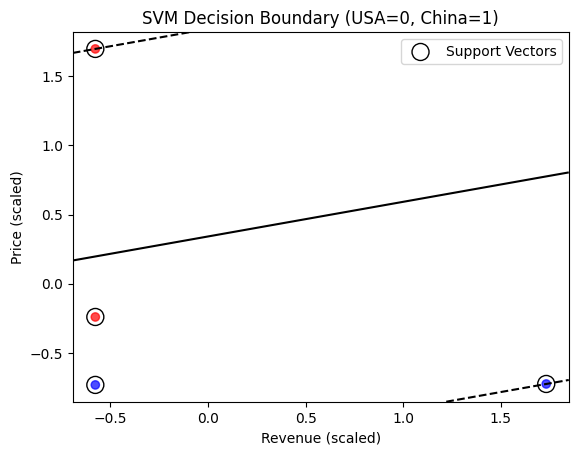

In [ ]:
# Assuming svm is your trained SVM model from the previous cell

# Plot the data points using scaled features
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='bwr', alpha=0.7)

# Plot decision boundary and margins
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a meshgrid for plotting the decision boundary
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50),
                     np.linspace(ylim[0], ylim[1], 50))

# Use the 'svm' model to get decision function values
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0], colors='k')       # decision boundary
plt.contour(xx, yy, Z, levels=[-1, 1], linestyles=['--','--'], colors='k')  # margins

# Highlight support vectors
# Use 'svm.support_vectors_' from the trained model
plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', label='Support Vectors')

plt.xlabel("Revenue (scaled)")
plt.ylabel("Price (scaled)")
plt.title("SVM Decision Boundary (USA=0, China=1)")
plt.legend()
plt.show()

Key Elements in the Diagram
Data Points:

Blue circles = USA (class 0)
Red circles = China (class 1)

Support Vectors (outlined points):

These are the most important data points.

They lie closest to the decision boundary and directly determine its position.

Decision Boundary (solid line):

This is the dividing line where the SVM predicts equal probability between the two classes.

Points on this line are “on the fence” between USA and China.

Margins (dashed lines):

These are parallel lines on either side of the boundary.

The SVM maximizes the distance between them to achieve the best separation.

Support vectors lie on or inside these margins.

What It Means
The SVM is trying to find the widest possible gap between the two classes while still correctly classifying the training points.

The support vectors anchor this gap — without them, the boundary could shift.

(with revenue and price scaled) can be plotted, and the SVM will classify it as USA or China depending on which side of the boundary it falls.

In short: the diagram is a visual explanation of how SVM works — showing the separation of classes, the role of support vectors, and the confidence margins.

Hyperparameter tuning

In [ ]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
import requests
from bs4 import BeautifulSoup
import numpy as np
import re

# --- 1. Data Acquisition (Web Scraping) ---
# Define the URL and headers for web scraping
url = "https://companiesmarketcap.com/e-commerce/largest-e-commerce-companies-by-revenue/"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

companies = []

# Extract data from the table rows
for row in soup.select("table tbody tr"):
    cols = row.find_all("td")

    # Ensure enough columns are present and extract relevant information
    if len(cols) >= 8: # Based on observation of the website structure
        company = cols[1].get_text(strip=True)
        revenue = cols[2].get_text(strip=True)
        price = cols[3].get_text(strip=True) # Using Market Cap (price) from the table

        country_element = cols[7].find("span", class_="responsive-hidden")
        country = country_element.get_text(strip=True) if country_element else cols[7].get_text(strip=True)

        companies.append([company, revenue, price, country])

df = pd.DataFrame(companies, columns=["Company","Revenue","Price","Country"])

# --- 2. Data Cleaning and Preprocessing ---

# Function to clean numeric values (e.g., Revenue, Price)
def clean_numeric(val):
    if pd.isna(val) or val == "":
        return np.nan

    val = str(val).replace('$','').replace(',','').strip()
    multiplier = 1

    if 'T' in val:
        multiplier = 1_000_000_000_000
        val = val.replace('T','')
    elif 'B' in val:
        multiplier = 1_000_000_000
        val = val.replace('B','')
    elif 'M' in val:
        multiplier = 1_000_000
        val = val.replace('M','')

    try:
        clean_val = ''.join(c for c in val if c.isdigit() or c == '.')
        if clean_val == '' and val != '':
            return np.nan
        return float(clean_val) * multiplier
    except ValueError:
        return np.nan

df["Revenue"] = df["Revenue"].apply(clean_numeric)
df["Price"] = df["Price"].apply(clean_numeric)
df.dropna(inplace=True)

# Function to clean and normalize country names
def clean_country(val):
    val = str(val).strip().upper()
    if "UNITED STATES" in val or "US" in val:
        return "USA"
    if "CHINA" in val or "CHINESE" in val:
        return "CHINA"
    val = re.sub(r'[^A-Z0-9]', '', val)
    return val

df["Country_clean"] = df["Country"].apply(clean_country)

# Filter the DataFrame to include only 'USA' and 'CHINA' for classification
df_filtered = df[df["Country_clean"].isin(["USA","CHINA"])].copy()

# --- 3. Feature Selection and Scaling ---
# Define features (X) and target (y)
X = df_filtered[['Revenue', 'Price']]
y = df_filtered['Country_clean']

# Encode target variable (Country) into numerical labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Scale the features to ensure fair contribution during model training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Due to the very small dataset, we use all samples for training and cross-validation
X_train = X_scaled
y_train = y

# --- 4. Hyperparameter Tuning using GridSearchCV ---
# Define the hyperparameter grid for the SVM model
param_grid = {
    'C': [0.1, 1, 10, 100], # Regularization parameter
    'gamma': [0.001, 0.01, 0.1, 1], # Kernel coefficient for 'rbf', 'poly' and 'sigmoid'
    'kernel': ['linear', 'rbf'] # Type of kernel function
}

# Initialize SVM classifier
svc = svm.SVC()

# Perform Grid Search with Cross-Validation
# cv=2 is chosen because there are only 2 samples per class in the filtered dataset.
# Using a higher cv value would lead to errors due to insufficient samples per split.
grid_search = GridSearchCV(svc, param_grid, cv=2, scoring='accuracy')
grid_search.fit(X_train, y_train)

# --- 5. Display Results ---
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

print("Note: No separate test set was used for evaluation due to the extremely small dataset.")
# print("Training Accuracy:", best_model.score(X_train, y_train)) # Uncomment to see training accuracy

Best Parameters: {'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}
Note: No separate test set was used for evaluation due to the extremely small dataset.


### Explanation of the Hyperparameter Tuning Code:

1.  **Data Acquisition (Web Scraping)**:
    *   The code first scrapes e-commerce company data (Company Name, Revenue, Market Cap, Country) from `companiesmarketcap.com` using `requests` and `BeautifulSoup`.
    *   It iterates through table rows and extracts the relevant text from each column.

2.  **Data Cleaning and Preprocessing**:
    *   **`clean_numeric` function**: This function converts string-based revenue and price values (e.g., "$691.33 B") into numerical format (e.g., 691.33 * 10^9), handling Trillions (T), Billions (B), and Millions (M) multipliers, and removing special characters.
    *   **`clean_country` function**: This function standardizes country names, specifically mapping variations of "United States" to "USA" and "China" to "CHINA", and removing other non-alphanumeric characters.
    *   **Filtering**: The `df_filtered` DataFrame is created to retain only companies from "USA" and "CHINA", as these were the target classes for the SVM classification in a previous context.

3.  **Feature Selection and Scaling**:
    *   **Features (X)**: 'Revenue' and 'Price' columns are selected as input features for the SVM model.
    *   **Target (y)**: The 'Country_clean' column (USA/CHINA) is set as the target variable.
    *   **Label Encoding**: The categorical target variable ('USA', 'CHINA') is converted into numerical labels (0 and 1) using `LabelEncoder`.
    *   **Standard Scaling**: Features are scaled using `StandardScaler` to have zero mean and unit variance. This is crucial for SVM performance, especially with features that have different scales.
    *   **Training Data**: Due to the extremely limited number of samples in the filtered dataset (after selecting only USA and China), all available data (`X_scaled`, `y`) is used as `X_train` and `y_train` for the hyperparameter search.

4.  **Hyperparameter Tuning using GridSearchCV**:
    *   **`param_grid`**: A dictionary is defined to specify the hyperparameters and their possible values to be tested for the SVM model:
        *   `C`: The regularization parameter. Smaller values mean stronger regularization.
        *   `gamma`: Kernel coefficient for 'rbf', 'poly', and 'sigmoid' kernels. It defines how far the influence of a single training example reaches.
        *   `kernel`: The type of kernel function to be used (`'linear'` or `'rbf'` in this case).
    *   **`GridSearchCV`**: This Scikit-learn function systematically works through multiple combinations of parameter values, cross-validating each combination to determine which gives the best performance (based on the `scoring` metric, which is 'accuracy' here).
    *   **`cv=2`**: The `cv` parameter specifies the number of folds for cross-validation. It's set to 2 because, with only 2 samples per class after filtering, this is the maximum possible number of splits without causing an error due to insufficient samples in each fold.

5.  **Display Results**:
    *   `grid_search.best_params_`: Prints the best combination of hyperparameters found by `GridSearchCV` that yielded the highest accuracy during cross-validation.
    *   `best_model`: Stores the SVM model trained with these optimal parameters.
    

Scraping: It collects data on the largest e‑commerce companies by revenue from the website (97 companies total).

Cleaning: Revenue and price values are converted into numeric form, and country names are standardized.

Filtering: The dataset is reduced to only USA and China companies as like SVM model

Preprocessing: Features (Revenue, Price) are scaled, and country labels are encoded (USA=0, China=1).

Hyperparameter Tuning: GridSearchCV tests different values of C, gamma, and kernel for the SVM model.

Result: The best parameters found were C=0.1, gamma=0.001, and kernel='linear'.


